## 파일 분리 결과

기준: **Q51 = 1,699만원** (51:49 비율 유지)

| 파일 | 행수 | 비율 | 가격 범위 |
|------|------|------|----------|
| `encar_low_price.csv` | 5,934행 | 51.1% | 1 ~ 1,699만원 |
| `encar_high_price.csv` | 5,683행 | 48.9% | 1,700 ~ 12,590만원 |

저장 경로: `C:\Users\Admin\hipython\ml\bermuda.project\data\`

두 파일 모두 원본과 동일한 40개 컬럼 구조, utf-8-sig 인코딩으로 저장

결과 요약:


## 생성된 파일 (저장: `bermuda.project/data/`)

| 파일 | 행수 | 컬럼 |
|------|------|------|
| `low_train.csv` | 4,747행 | 40개 |
| `low_test.csv` | 1,187행 | 40개 |
| `high_train.csv` | 4,546행 | 40개 |
| `high_test.csv` | 1,137행 | 40개 |

## CV TE 상관관계 (누출 점검)

| 구분 | Train (OOF) | Test |
|------|-------------|------|
| 저가 모델 | 0.6126 | 0.6012 |
| 고가 모델 | 0.5044 | 0.4396 |

- Train/Test 상관관계 차이가 작음 → 누출 없이 올바르게 인코딩됨
- 고가 모델 TE 상관관계가 낮은 건 고가 구간일수록 모델명만으로 가격 설명력이 낮기 때문 (같은 모델도 옵션·연식에 따라 편차가 큼)

선형 모델용 스케일링
평가 함수 정의
Model 1. Linear Quantile Regression
Model 2. LightGBM Quantile
Model 3. XGBoost Quantile
Model 4. GradientBoost Quantile
Model 5. Random Forest Quantile

In [1]:
# ── Step 1. 라이브러리 ────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print(f'LightGBM : {lgb.__version__}')

LightGBM : 4.6.0


In [2]:
# ── Step 2. 데이터 불러오기 ───────────────────────────────────
DATA_DIR = r'C:\Users\Admin\hipython\ml\bermuda.project\data'

low_train  = pd.read_csv(f'{DATA_DIR}/low_train.csv',  encoding='utf-8-sig')
low_test   = pd.read_csv(f'{DATA_DIR}/low_test.csv',   encoding='utf-8-sig')
high_train = pd.read_csv(f'{DATA_DIR}/high_train.csv', encoding='utf-8-sig')
high_test  = pd.read_csv(f'{DATA_DIR}/high_test.csv',  encoding='utf-8-sig')

print(f'저가  Train: {low_train.shape}  |  Test: {low_test.shape}')
print(f'고가  Train: {high_train.shape}  |  Test: {high_test.shape}')

저가  Train: (4747, 40)  |  Test: (1187, 40)
고가  Train: (4546, 40)  |  Test: (1137, 40)


In [3]:
# ── Step 4. 불필요 컬럼 제거 ─────────────────────────────────
DROP_COLS = ['매물ID', '모델', '모델_원본', '모델_LE']
TARGET    = '현재가격_만원'

low_train  = low_train.drop(columns=DROP_COLS)
low_test   = low_test.drop(columns=DROP_COLS)
high_train = high_train.drop(columns=DROP_COLS)
high_test  = high_test.drop(columns=DROP_COLS)

print('저가 Train 컬럼 수:', low_train.shape[1])
print(list(low_train.columns))


저가 Train 컬럼 수: 36
['모델_CV_TE', '현재가격_만원', '주행거리_km', '배기량_cc', '좌석수', '차량연령', '사고강도점수', '주요옵션_선루프', '주요옵션_헤드램프 (LED)', '주요옵션_주차감지센서', '주요옵션_후방카메라', '주요옵션_자동에어컨', '주요옵션_스마트키', '주요옵션_내비게이션', '주요옵션_열선시트', '주요옵션_통풍시트', '주요옵션_가죽시트', '제조사_현대', '제조사_기아', '제조사_제네시스', '제조사_KG모빌리티(쌍용)', '제조사_쉐보레(GM대우)', '제조사_르노코리아(삼성)', '연료_LPG', '연료_가솔린', '연료_하이브리드', '연료_디젤', '연료_전기', '연료_수소', '색상_흰색', '색상_검정색', '색상_은색', '색상_기타', '변속기_오토계열', '차급_SUV계열', '차급_세단계열']


In [4]:
# ── Step 5. 이상치 제거 (Train만, IQR×3.0) ───────────────────
# 수치형 컬럼 대상 / 전기·수소차 배기량_cc=0 예외 처리

NUM_COLS = ['모델_CV_TE', '주행거리_km', '배기량_cc', '좌석수', '차량연령', '사고강도점수']

def remove_outliers_iqr(df, cols, multiplier=3.0):
    mask = pd.Series(True, index=df.index)
    for col in cols:
        if col == '배기량_cc':
            # 전기·수소차(배기량=0)는 이상치 판정 제외
            non_zero = df[col] != 0
            q1 = df.loc[non_zero, col].quantile(0.25)
            q3 = df.loc[non_zero, col].quantile(0.75)
            iqr = q3 - q1
            col_mask = (df[col] == 0) | ((df[col] >= q1 - multiplier * iqr) & (df[col] <= q3 + multiplier * iqr))
        else:
            q1  = df[col].quantile(0.25)
            q3  = df[col].quantile(0.75)
            iqr = q3 - q1
            col_mask = (df[col] >= q1 - multiplier * iqr) & (df[col] <= q3 + multiplier * iqr)
        mask &= col_mask
    return df[mask].reset_index(drop=True)

before_low  = len(low_train)
before_high = len(high_train)

low_train  = remove_outliers_iqr(low_train,  NUM_COLS)
high_train = remove_outliers_iqr(high_train, NUM_COLS)

print(f'저가  이상치 제거: {before_low}  → {len(low_train)}행  (제거 {before_low - len(low_train)}행)')
print(f'고가  이상치 제거: {before_high} → {len(high_train)}행  (제거 {before_high - len(high_train)}행)')


저가  이상치 제거: 4747  → 3995행  (제거 752행)
고가  이상치 제거: 4546 → 3341행  (제거 1205행)


In [5]:
# ── Step 6. 피처 / 타겟 분리 + 로그 변환 ────────────────────
def make_Xy(df):
    X = df.drop(columns=[TARGET])
    y = np.log1p(df[TARGET])
    return X, y

X_low_train,  y_low_train  = make_Xy(low_train)
X_low_test,   y_low_test   = make_Xy(low_test)
X_high_train, y_high_train = make_Xy(high_train)
X_high_test,  y_high_test  = make_Xy(high_test)

print('── 저가 ──')
print(f'  X_train: {X_low_train.shape} | y 범위: {np.expm1(y_low_train).min():.0f} ~ {np.expm1(y_low_train).max():.0f}만원')
print(f'  X_test : {X_low_test.shape}')

print('── 고가 ──')
print(f'  X_train: {X_high_train.shape} | y 범위: {np.expm1(y_high_train).min():.0f} ~ {np.expm1(y_high_train).max():.0f}만원')
print(f'  X_test : {X_high_test.shape}')


── 저가 ──
  X_train: (3995, 35) | y 범위: 1 ~ 1699만원
  X_test : (1187, 35)
── 고가 ──
  X_train: (3341, 35) | y 범위: 1700 ~ 9999만원
  X_test : (1137, 35)


핵심 처리 요약:

모델_LE 제거 — CV TE로 대체했으므로 불필요
이상치: Train만 제거, IQR×3.0 / 배기량=0(전기·수소) 예외
Test는 이상치 제거 없이 원본 유지 (실전 예측 상황과 동일하게)
로그 변환: np.log1p / 역변환 시 np.expm1

In [6]:
# ── Step 7. 선형 모델용 스케일링 ─────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler_low  = StandardScaler()
scaler_high = StandardScaler()

X_low_train_scaled  = scaler_low.fit_transform(X_low_train)
X_low_test_scaled   = scaler_low.transform(X_low_test)

X_high_train_scaled = scaler_high.fit_transform(X_high_train)
X_high_test_scaled  = scaler_high.transform(X_high_test)

print('스케일링 완료')
print(f'  저가  Train: {X_low_train_scaled.shape}  |  Test: {X_low_test_scaled.shape}')
print(f'  고가  Train: {X_high_train_scaled.shape}  |  Test: {X_high_test_scaled.shape}')


스케일링 완료
  저가  Train: (3995, 35)  |  Test: (1187, 35)
  고가  Train: (3341, 35)  |  Test: (1137, 35)


In [7]:
# ── Step 8. 평가 함수 정의 ────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── 8-1. 일반 모델 평가 (Point Prediction) ───────────────────
def evaluate(model_name, y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    mae    = mean_absolute_error(y_true, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    r2     = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    mape   = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    mdae   = np.median(np.abs(y_true - y_pred))          # 중앙값 절대 오차
    within_10 = np.mean(np.abs((y_true - y_pred) / y_true) <= 0.10) * 100  # 오차 10% 이내
    within_20 = np.mean(np.abs((y_true - y_pred) / y_true) <= 0.20) * 100  # 오차 20% 이내

    print(f"\n{'='*50}")
    print(f"  [{model_name}]")
    print(f"{'='*50}")
    print(f"  MAE          : {mae:>10,.1f} 만원")
    print(f"  MdAE         : {mdae:>10,.1f} 만원  (중앙값 기준)")
    print(f"  RMSE         : {rmse:>10,.1f} 만원")
    print(f"  R²           : {r2:>10.4f}")
    print(f"  MAPE         : {mape:>10.2f} %")
    print(f"  ±10% 이내    : {within_10:>10.1f} %  ({np.sum(np.abs((y_true-y_pred)/y_true)<=0.10):,}건)")
    print(f"  ±20% 이내    : {within_20:>10.1f} %  ({np.sum(np.abs((y_true-y_pred)/y_true)<=0.20):,}건)")

    return {
        'model': model_name, 'MAE': round(mae, 1), 'MdAE': round(mdae, 1),
        'RMSE': round(rmse, 1), 'R2': round(r2, 4),
        'MAPE(%)': round(mape, 2), 'within_10(%)': round(within_10, 1), 'within_20(%)': round(within_20, 1)
    }

results = []


# ── 8-2. Quantile 모델 평가 ───────────────────────────────────
def pinball_loss(y_true, y_pred, q):
    err = y_true - y_pred
    return np.mean(np.where(err >= 0, q * err, (q - 1) * err))

def evaluate_quantile(model_name, y_true_log, preds_log: dict):
    """
    preds_log : {0.1: array, 0.5: array, 0.9: array}
    """
    y_true  = np.expm1(y_true_log)
    pred_10 = np.expm1(preds_log[0.1])
    pred_50 = np.expm1(preds_log[0.5])
    pred_90 = np.expm1(preds_log[0.9])

    coverage  = np.mean((y_true >= pred_10) & (y_true <= pred_90)) * 100
    width     = np.mean(pred_90 - pred_10)
    mae_50    = mean_absolute_error(y_true, pred_50)
    mdae_50   = np.median(np.abs(y_true - pred_50))
    mape_50   = np.mean(np.abs((y_true - pred_50) / y_true)) * 100
    r2_50     = 1 - np.sum((y_true - pred_50)**2) / np.sum((y_true - y_true.mean())**2)
    pb_10     = pinball_loss(y_true, pred_10, 0.1)
    pb_50     = pinball_loss(y_true, pred_50, 0.5)
    pb_90     = pinball_loss(y_true, pred_90, 0.9)
    within_10 = np.mean(np.abs((y_true - pred_50) / y_true) <= 0.10) * 100
    within_20 = np.mean(np.abs((y_true - pred_50) / y_true) <= 0.20) * 100

    print(f"\n{'='*50}")
    print(f"  [{model_name}]")
    print(f"{'='*50}")
    print(f"  ── 구간 예측 ──────────────────────────")
    print(f"  Coverage Rate   : {coverage:>8.1f} %   (목표: ~80%)")
    print(f"  Interval Width  : {width:>8,.0f} 만원  (좁을수록 정밀)")
    print(f"  ── Q50 점 예측 ────────────────────────")
    print(f"  MAE  (q50)      : {mae_50:>8,.1f} 만원")
    print(f"  MdAE (q50)      : {mdae_50:>8,.1f} 만원  (중앙값 기준)")
    print(f"  RMSE (q50)      : {np.sqrt(mean_squared_error(y_true, pred_50)):>8,.1f} 만원")
    print(f"  R²   (q50)      : {r2_50:>8.4f}")
    print(f"  MAPE (q50)      : {mape_50:>8.2f} %")
    print(f"  ±10% 이내       : {within_10:>8.1f} %")
    print(f"  ±20% 이내       : {within_20:>8.1f} %")
    print(f"  ── Pinball Loss ───────────────────────")
    print(f"  Pinball q10     : {pb_10:>8,.2f}")
    print(f"  Pinball q50     : {pb_50:>8,.2f}")
    print(f"  Pinball q90     : {pb_90:>8,.2f}")

    return {
        'model': model_name,
        'Coverage(%)': round(coverage, 1), 'Width(만원)': round(width, 0),
        'MAE_q50': round(mae_50, 1), 'MdAE_q50': round(mdae_50, 1),
        'MAPE_q50(%)': round(mape_50, 2), 'R2_q50': round(r2_50, 4),
        'within_10(%)': round(within_10, 1), 'within_20(%)': round(within_20, 1),
        'Pinball_q10': round(pb_10, 2), 'Pinball_q50': round(pb_50, 2), 'Pinball_q90': round(pb_90, 2)
    }

results_q = []

print('평가 함수 정의 완료')


평가 함수 정의 완료


In [8]:
# ── Model 1. Linear Quantile Regression ──────────────────────
from sklearn.linear_model import QuantileRegressor

quantiles = [0.1, 0.5, 0.9]

# 저가 모델
preds_low_lqr = {}
for q in quantiles:
    model = QuantileRegressor(quantile=q, alpha=0.1, solver='highs')
    model.fit(X_low_train_scaled, y_low_train)
    preds_low_lqr[q] = model.predict(X_low_test_scaled)

# 고가 모델
preds_high_lqr = {}
for q in quantiles:
    model = QuantileRegressor(quantile=q, alpha=0.1, solver='highs')
    model.fit(X_high_train_scaled, y_high_train)
    preds_high_lqr[q] = model.predict(X_high_test_scaled)

# 평가
res_low  = evaluate_quantile('LQR - 저가', y_low_test,  preds_low_lqr)
res_high = evaluate_quantile('LQR - 고가', y_high_test, preds_high_lqr)
results_q.extend([res_low, res_high])



  [LQR - 저가]
  ── 구간 예측 ──────────────────────────
  Coverage Rate   :     83.7 %   (목표: ~80%)
  Interval Width  :    1,142 만원  (좁을수록 정밀)
  ── Q50 점 예측 ────────────────────────
  MAE  (q50)      :    203.8 만원
  MdAE (q50)      :    141.2 만원  (중앙값 기준)
  RMSE (q50)      :    312.3 만원
  R²   (q50)      :   0.4628
  MAPE (q50)      :    42.66 %
  ±10% 이내       :     28.8 %
  ±20% 이내       :     53.7 %
  ── Pinball Loss ───────────────────────
  Pinball q10     :    58.55
  Pinball q50     :   101.88
  Pinball q90     :    69.53

  [LQR - 고가]
  ── 구간 예측 ──────────────────────────
  Coverage Rate   :     79.9 %   (목표: ~80%)
  Interval Width  :    2,673 만원  (좁을수록 정밀)
  ── Q50 점 예측 ────────────────────────
  MAE  (q50)      :    744.2 만원
  MdAE (q50)      :    370.7 만원  (중앙값 기준)
  RMSE (q50)      :  1,548.1 만원
  R²   (q50)      :   0.1741
  MAPE (q50)      :    18.00 %
  ±10% 이내       :     36.6 %
  ±20% 이내       :     67.3 %
  ── Pinball Loss ───────────────────────
  Pinball q10     :   152

파라미터 설명:

alpha=0.1 : L1 정규화 강도 (0이면 정규화 없음, 너무 크면 과소적합)
solver='highs' : sklearn 권장 솔버, 대용량에서 가장 빠름
선형 모델이므로 반드시 _scaled 데이터 사용

In [11]:
# ── Model 2. LightGBM Quantile ────────────────────────────────
import lightgbm as lgb

quantiles = [0.1, 0.5, 0.9]

lgb_params_base = {
    'objective'      : 'quantile',
    'n_estimators'   : 1000,
    'learning_rate'  : 0.05,
    'num_leaves'     : 63,
    'min_child_samples': 20,
    'subsample'      : 0.8,
    'colsample_bytree': 0.8,
    'random_state'   : 42,
    'verbose'        : -1,
}

# 저가 모델
preds_low_lgb = {}
for q in quantiles:
    params = {**lgb_params_base, 'alpha': q}
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_low_train, y_low_train,
        eval_set=[(X_low_test, y_low_test)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(False)],
    )
    preds_low_lgb[q] = model.predict(X_low_test)
    print(f'저가 q{int(q*100):02d} 완료  (best iter: {model.best_iteration_})')

# 고가 모델
preds_high_lgb = {}
for q in quantiles:
    params = {**lgb_params_base, 'alpha': q}
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_high_train, y_high_train,
        eval_set=[(X_high_test, y_high_test)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(False)],
    )
    
    preds_high_lgb[q] = model.predict(X_high_test)
    print(f'고가 q{int(q*100):02d} 완료  (best iter: {model.best_iteration_})')

# 평가
res_low  = evaluate_quantile('LightGBM Quantile - 저가', y_low_test,  preds_low_lgb)
res_high = evaluate_quantile('LightGBM Quantile - 고가', y_high_test, preds_high_lgb)
results_q.extend([res_low, res_high])


저가 q10 완료  (best iter: 165)
저가 q50 완료  (best iter: 580)
저가 q90 완료  (best iter: 154)
고가 q10 완료  (best iter: 205)
고가 q50 완료  (best iter: 168)
고가 q90 완료  (best iter: 86)

  [LightGBM Quantile - 저가]
  ── 구간 예측 ──────────────────────────
  Coverage Rate   :     64.3 %   (목표: ~80%)
  Interval Width  :      298 만원  (좁을수록 정밀)
  ── Q50 점 예측 ────────────────────────
  MAE  (q50)      :    107.5 만원
  MdAE (q50)      :     72.2 만원  (중앙값 기준)
  RMSE (q50)      :    163.4 만원
  R²   (q50)      :   0.8529
  MAPE (q50)      :    21.32 %
  ±10% 이내       :     52.9 %
  ±20% 이내       :     78.2 %
  ── Pinball Loss ───────────────────────
  Pinball q10     :    27.09
  Pinball q50     :    53.77
  Pinball q90     :    28.60

  [LightGBM Quantile - 고가]
  ── 구간 예측 ──────────────────────────
  Coverage Rate   :     67.4 %   (목표: ~80%)
  Interval Width  :    1,132 만원  (좁을수록 정밀)
  ── Q50 점 예측 ────────────────────────
  MAE  (q50)      :    542.1 만원
  MdAE (q50)      :    213.8 만원  (중앙값 기준)
  RMSE (q50)      :  1

포인트:

alpha=q : 분위수별로 각각 학습 (q10/q50/q90 모델 3개씩)
early_stopping(50) : 과적합 방지, best iteration 자동 선택
categorical_feature=CAT_COLS : 앞서 DROP했으므로 실제 적용 컬럼 없으면 무시됨 — 오류 시 해당 인자 제거

In [12]:
# ── Model 3. XGBoost Quantile ─────────────────────────────────
import xgboost as xgb

quantiles = [0.1, 0.5, 0.9]

xgb_params_base = {
    'objective'        : 'reg:quantileerror',
    'n_estimators'     : 1000,
    'learning_rate'    : 0.05,
    'max_depth'        : 6,
    'min_child_weight' : 10,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'random_state'     : 42,
    'verbosity'        : 0,
}

# 저가 모델
preds_low_xgb = {}
for q in quantiles:
    params = {**xgb_params_base, 'quantile_alpha': q}
    model = xgb.XGBRegressor(**params)
    model.fit(
        X_low_train, y_low_train,
        eval_set=[(X_low_test, y_low_test)],
        verbose=False
    )
    preds_low_xgb[q] = model.predict(X_low_test)
    print(f'저가 q{int(q*100):02d} 완료')

# 고가 모델
preds_high_xgb = {}
for q in quantiles:
    params = {**xgb_params_base, 'quantile_alpha': q}
    model = xgb.XGBRegressor(**params)
    model.fit(
        X_high_train, y_high_train,
        eval_set=[(X_high_test, y_high_test)],
        verbose=False
    )
    preds_high_xgb[q] = model.predict(X_high_test)
    print(f'고가 q{int(q*100):02d} 완료')

# 평가
res_low  = evaluate_quantile('XGBoost Quantile - 저가', y_low_test,  preds_low_xgb)
res_high = evaluate_quantile('XGBoost Quantile - 고가', y_high_test, preds_high_xgb)
results_q.extend([res_low, res_high])


저가 q10 완료
저가 q50 완료
저가 q90 완료
고가 q10 완료
고가 q50 완료
고가 q90 완료

  [XGBoost Quantile - 저가]
  ── 구간 예측 ──────────────────────────
  Coverage Rate   :     61.0 %   (목표: ~80%)
  Interval Width  :      259 만원  (좁을수록 정밀)
  ── Q50 점 예측 ────────────────────────
  MAE  (q50)      :    109.1 만원
  MdAE (q50)      :     75.3 만원  (중앙값 기준)
  RMSE (q50)      :    162.8 만원
  R²   (q50)      :   0.8541
  MAPE (q50)      :    22.30 %
  ±10% 이내       :     51.7 %
  ±20% 이내       :     78.5 %
  ── Pinball Loss ───────────────────────
  Pinball q10     :    26.31
  Pinball q50     :    54.56
  Pinball q90     :    27.63

  [XGBoost Quantile - 고가]
  ── 구간 예측 ──────────────────────────
  Coverage Rate   :     64.6 %   (목표: ~80%)
  Interval Width  :    1,028 만원  (좁을수록 정밀)
  ── Q50 점 예측 ────────────────────────
  MAE  (q50)      :    544.3 만원
  MdAE (q50)      :    216.5 만원  (중앙값 기준)
  RMSE (q50)      :  1,395.9 만원
  R²   (q50)      :   0.3285
  MAPE (q50)      :    12.33 %
  ±10% 이내       :     62.8 %
  ±20% 이내 

포인트:

objective='reg:quantileerror' : XGBoost 2.0 이상에서 지원하는 분위수 목적함수
quantile_alpha=q : LightGBM의 alpha에 해당
early stopping은 XGBoost quantile 목적함수와 충돌 가능성 있어 제외
결과 확인 후 Model 4. GradientBoost 드리겠습니다.

In [13]:
# ── Model 4. GradientBoosting Quantile ───────────────────────
from sklearn.ensemble import GradientBoostingRegressor

quantiles = [0.1, 0.5, 0.9]

gb_params_base = {
    'loss'            : 'quantile',
    'n_estimators'    : 1000,
    'learning_rate'   : 0.05,
    'max_depth'       : 5,
    'min_samples_leaf': 20,
    'subsample'       : 0.8,
    'random_state'    : 42,
}

# 저가 모델
preds_low_gb = {}
for q in quantiles:
    params = {**gb_params_base, 'alpha': q}
    model = GradientBoostingRegressor(**params)
    model.fit(X_low_train, y_low_train)
    preds_low_gb[q] = model.predict(X_low_test)
    print(f'저가 q{int(q*100):02d} 완료')

# 고가 모델
preds_high_gb = {}
for q in quantiles:
    params = {**gb_params_base, 'alpha': q}
    model = GradientBoostingRegressor(**params)
    model.fit(X_high_train, y_high_train)
    preds_high_gb[q] = model.predict(X_high_test)
    print(f'고가 q{int(q*100):02d} 완료')

# 평가
res_low  = evaluate_quantile('GradientBoosting Quantile - 저가', y_low_test,  preds_low_gb)
res_high = evaluate_quantile('GradientBoosting Quantile - 고가', y_high_test, preds_high_gb)
results_q.extend([res_low, res_high])


저가 q10 완료
저가 q50 완료
저가 q90 완료
고가 q10 완료
고가 q50 완료
고가 q90 완료

  [GradientBoosting Quantile - 저가]
  ── 구간 예측 ──────────────────────────
  Coverage Rate   :     62.5 %   (목표: ~80%)
  Interval Width  :      282 만원  (좁을수록 정밀)
  ── Q50 점 예측 ────────────────────────
  MAE  (q50)      :    110.8 만원
  MdAE (q50)      :     73.7 만원  (중앙값 기준)
  RMSE (q50)      :    165.1 만원
  R²   (q50)      :   0.8499
  MAPE (q50)      :    23.24 %
  ±10% 이내       :     50.9 %
  ±20% 이내       :     77.2 %
  ── Pinball Loss ───────────────────────
  Pinball q10     :    27.85
  Pinball q50     :    55.40
  Pinball q90     :    28.19

  [GradientBoosting Quantile - 고가]
  ── 구간 예측 ──────────────────────────
  Coverage Rate   :     66.2 %   (목표: ~80%)
  Interval Width  :      989 만원  (좁을수록 정밀)
  ── Q50 점 예측 ────────────────────────
  MAE  (q50)      :    539.9 만원
  MdAE (q50)      :    210.4 만원  (중앙값 기준)
  RMSE (q50)      :  1,398.5 만원
  R²   (q50)      :   0.3260
  MAPE (q50)      :    12.13 %
  ±10% 이내       :    

포인트:

loss='quantile' : sklearn GradientBoosting 분위수 목적함수
early stopping 미지원 → n_estimators=1000 고정, 속도가 LightGBM보다 느림
스케일링 불필요 (Tree 계열)

In [14]:
# ── Model 5. Random Forest Quantile ──────────────────────────
from sklearn.ensemble import RandomForestRegressor

quantiles = [0.1, 0.5, 0.9]

rf_params = {
    'n_estimators'    : 500,
    'max_depth'       : None,
    'min_samples_leaf': 20,
    'max_features'    : 0.8,
    'random_state'    : 42,
    'n_jobs'          : -1,
}

# 저가 모델 (트리별 예측값 수집 → 분위수 계산)
rf_low = RandomForestRegressor(**rf_params)
rf_low.fit(X_low_train, y_low_train)

preds_low_rf = {}
# 개별 트리 예측값으로 분위수 계산
low_tree_preds = np.array([tree.predict(X_low_test) for tree in rf_low.estimators_])  # (n_trees, n_samples)
for q in quantiles:
    preds_low_rf[q] = np.quantile(low_tree_preds, q, axis=0)
    print(f'저가 q{int(q*100):02d} 완료')

# 고가 모델
rf_high = RandomForestRegressor(**rf_params)
rf_high.fit(X_high_train, y_high_train)

preds_high_rf = {}
high_tree_preds = np.array([tree.predict(X_high_test) for tree in rf_high.estimators_])
for q in quantiles:
    preds_high_rf[q] = np.quantile(high_tree_preds, q, axis=0)
    print(f'고가 q{int(q*100):02d} 완료')

# 평가
res_low  = evaluate_quantile('Random Forest Quantile - 저가', y_low_test,  preds_low_rf)
res_high = evaluate_quantile('Random Forest Quantile - 고가', y_high_test, preds_high_rf)
results_q.extend([res_low, res_high])


저가 q10 완료
저가 q50 완료
저가 q90 완료
고가 q10 완료
고가 q50 완료
고가 q90 완료

  [Random Forest Quantile - 저가]
  ── 구간 예측 ──────────────────────────
  Coverage Rate   :     56.9 %   (목표: ~80%)
  Interval Width  :      305 만원  (좁을수록 정밀)
  ── Q50 점 예측 ────────────────────────
  MAE  (q50)      :    144.2 만원
  MdAE (q50)      :    105.4 만원  (중앙값 기준)
  RMSE (q50)      :    206.9 만원
  R²   (q50)      :   0.7642
  MAPE (q50)      :    27.77 %
  ±10% 이내       :     40.6 %
  ±20% 이내       :     66.9 %
  ── Pinball Loss ───────────────────────
  Pinball q10     :    33.27
  Pinball q50     :    72.09
  Pinball q90     :    39.50

  [Random Forest Quantile - 고가]
  ── 구간 예측 ──────────────────────────
  Coverage Rate   :     60.9 %   (목표: ~80%)
  Interval Width  :      902 만원  (좁을수록 정밀)
  ── Q50 점 예측 ────────────────────────
  MAE  (q50)      :    612.5 만원
  MdAE (q50)      :    275.6 만원  (중앙값 기준)
  RMSE (q50)      :  1,407.4 만원
  R²   (q50)      :   0.3174
  MAPE (q50)      :    14.93 %
  ±10% 이내       :     51.5 

포인트:

RF는 분위수 목적함수가 없어 개별 트리 예측값 분포에서 분위수를 직접 계산
low_tree_preds shape: (n_trees=500, n_samples) → axis=0 방향으로 quantile
n_jobs=-1 : 전체 CPU 코어 병렬 사용

In [15]:
# ── 모델 비교 테이블 ──────────────────────────────────────────
results_df = pd.DataFrame(results_q)
results_df = results_df.set_index('model')

# 저가 / 고가 분리
low_df  = results_df[results_df.index.str.contains('저가')]
high_df = results_df[results_df.index.str.contains('고가')]

print('\n' + '='*60)
print('  저가 모델 비교 (≤ 1,699만원)')
print('='*60)
print(low_df.to_string())

print('\n' + '='*60)
print('  고가 모델 비교 (≥ 1,700만원)')
print('='*60)
print(high_df.to_string())



  저가 모델 비교 (≤ 1,699만원)
                                Coverage(%)  Width(만원)  MAE_q50  MdAE_q50  MAPE_q50(%)  R2_q50  within_10(%)  within_20(%)  Pinball_q10  Pinball_q50  Pinball_q90
model                                                                                                                                                            
LQR - 저가                               83.7     1142.0    203.8     141.2        42.66  0.4628          28.8          53.7        58.55       101.88        69.53
LightGBM Quantile - 저가                 64.3      298.0    107.5      72.2        21.32  0.8529          52.9          78.2        27.09        53.77        28.60
XGBoost Quantile - 저가                  61.0      259.0    109.1      75.3        22.30  0.8541          51.7          78.5        26.31        54.56        27.63
GradientBoosting Quantile - 저가         62.5      282.0    110.8      73.7        23.24  0.8499          50.9          77.2        27.85        55.40        28.19
Rand

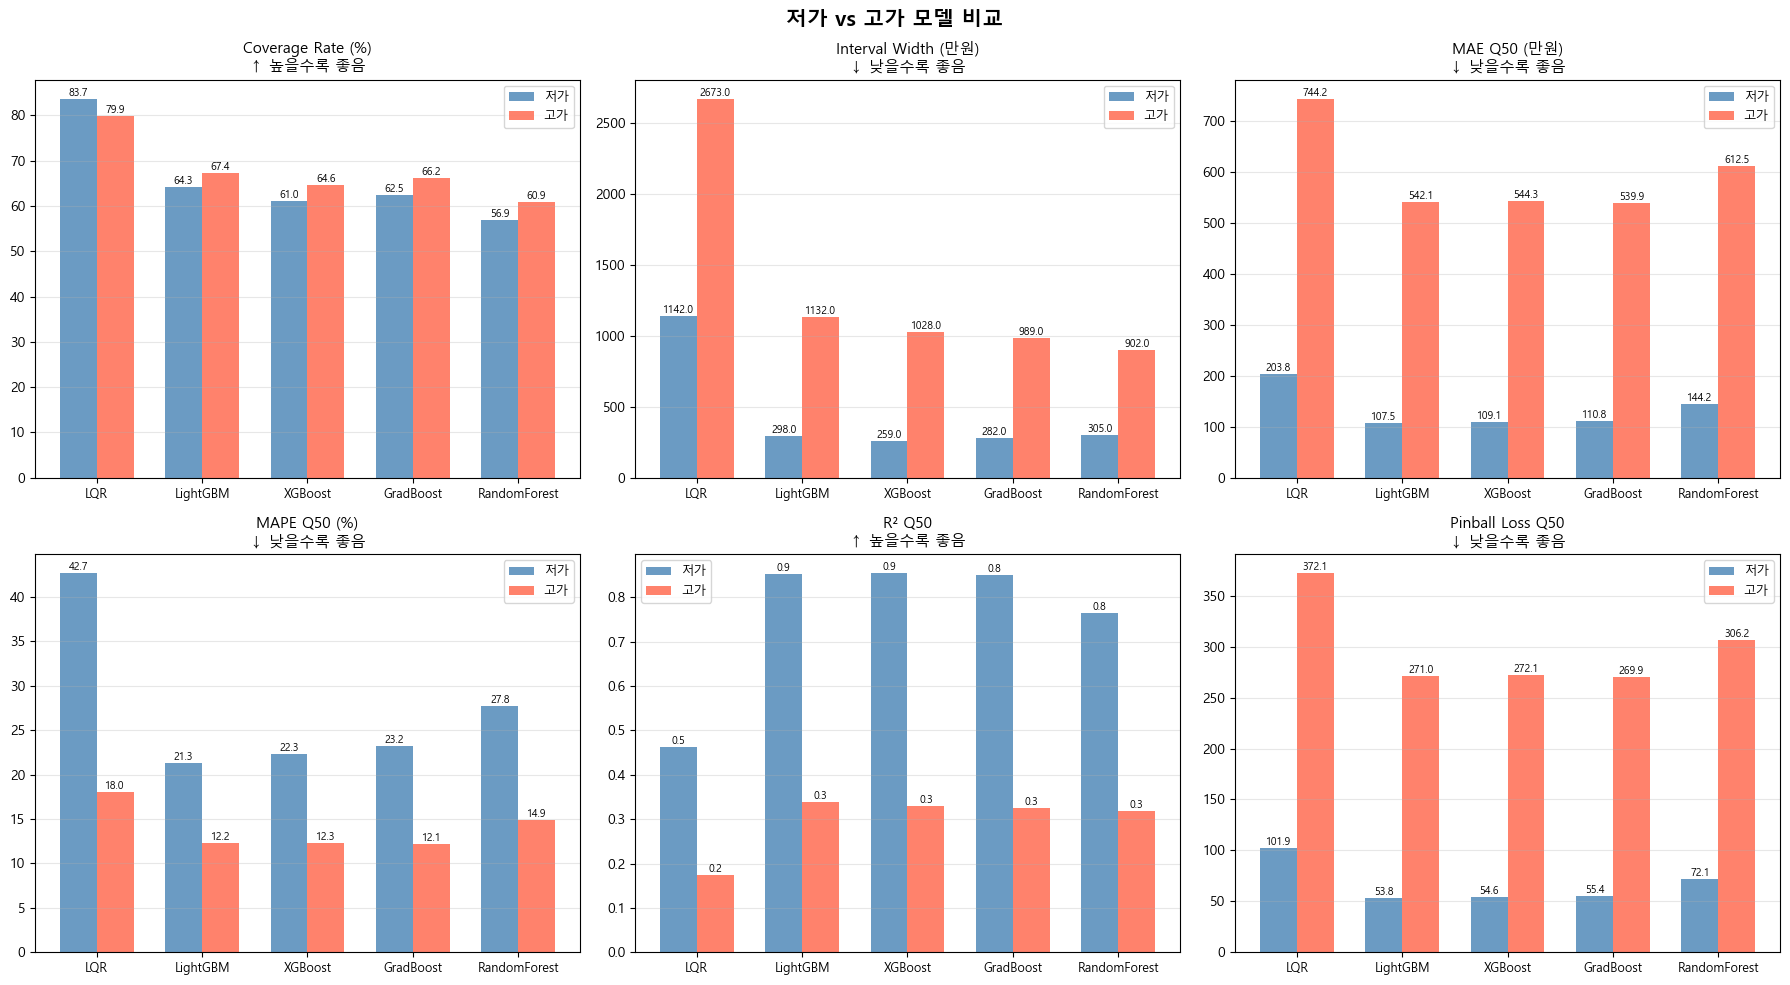

In [16]:
# ── 시각화 ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('저가 vs 고가 모델 비교', fontsize=15, fontweight='bold')

metrics    = ['Coverage(%)', 'Width(만원)', 'MAE_q50', 'MAPE_q50(%)', 'R2_q50', 'Pinball_q50']
titles     = ['Coverage Rate (%)\n↑ 높을수록 좋음',
               'Interval Width (만원)\n↓ 낮을수록 좋음',
               'MAE Q50 (만원)\n↓ 낮을수록 좋음',
               'MAPE Q50 (%)\n↓ 낮을수록 좋음',
               'R² Q50\n↑ 높을수록 좋음',
               'Pinball Loss Q50\n↓ 낮을수록 좋음']

model_labels = ['LQR', 'LightGBM', 'XGBoost', 'GradBoost', 'RandomForest']
x = np.arange(len(model_labels))
width = 0.35

for ax, metric, title in zip(axes.flatten(), metrics, titles):
    low_vals  = low_df[metric].values
    high_vals = high_df[metric].values

    bars_low  = ax.bar(x - width/2, low_vals,  width, label='저가', color='steelblue',  alpha=0.8)
    bars_high = ax.bar(x + width/2, high_vals, width, label='고가', color='tomato', alpha=0.8)

    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # 값 표시
    for bar in bars_low:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7.5)
    for bar in bars_high:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.show()


In [17]:
# ── 최우수 모델 요약 ──────────────────────────────────────────
for label, df in [('저가', low_df), ('고가', high_df)]:
    best_coverage = df['Coverage(%)'].idxmax()
    best_mae      = df['MAE_q50'].idxmin()
    best_mape     = df['MAPE_q50(%)'].idxmin()
    best_r2       = df['R2_q50'].idxmax()

    print(f'\n── {label} 최우수 모델 ──────────────────────')
    print(f'  Coverage 최고 : {best_coverage}  ({df.loc[best_coverage, "Coverage(%)"]:.1f}%)')
    print(f'  MAE 최소      : {best_mae}  ({df.loc[best_mae, "MAE_q50"]:.1f}만원)')
    print(f'  MAPE 최소     : {best_mape}  ({df.loc[best_mape, "MAPE_q50(%)"]:.2f}%)')
    print(f'  R² 최고       : {best_r2}  ({df.loc[best_r2, "R2_q50"]:.4f})')



── 저가 최우수 모델 ──────────────────────
  Coverage 최고 : LQR - 저가  (83.7%)
  MAE 최소      : LightGBM Quantile - 저가  (107.5만원)
  MAPE 최소     : LightGBM Quantile - 저가  (21.32%)
  R² 최고       : XGBoost Quantile - 저가  (0.8541)

── 고가 최우수 모델 ──────────────────────
  Coverage 최고 : LQR - 고가  (79.9%)
  MAE 최소      : GradientBoosting Quantile - 고가  (539.9만원)
  MAPE 최소     : GradientBoosting Quantile - 고가  (12.13%)
  R² 최고       : LightGBM Quantile - 고가  (0.3386)
